# 1. Подготовка данных и их анализ

## 1.1 Импорт необходимых библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import yaml

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1.2. Загрузка параметров и данных

In [2]:
# Загрузка параметров из params.yaml
with open('params.yaml', 'r') as f:
    params = yaml.safe_load(f)

eda_params = params['eda']

# Загрузка датасета
data_path = 'data/raw/insurance.csv'
df = pd.read_csv(data_path)

print("="*80)
print("EDA АНАЛИЗ ДАТАСЕТА МЕДИЦИНСКОГО СТРАХОВАНИЯ")
print("="*80)
print(f"\nРазмер датасета: {df.shape}")
print(f"\nПервые 5 строк датасета:")
df.head()

EDA АНАЛИЗ ДАТАСЕТА МЕДИЦИНСКОГО СТРАХОВАНИЯ

Размер датасета: (1244, 7)

Первые 5 строк датасета:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1.3. Информация о датасете

In [3]:
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*80)
print("\nТипы данных:")
print(df.dtypes)
print("\n\nСтатистическое описание числовых признаков:")
df.describe()

ИНФОРМАЦИЯ О ДАТАСЕТЕ

Типы данных:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


Статистическое описание числовых признаков:


,age,bmi,children,charges
count,1244.000000,1244.000000,1244.000000,1244.000000
mean,39.088424,30.582858,1.103698,13198.216342
std,14.055295,6.159513,1.215885,12001.805804
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.060000,0.000000,4733.635288
50%,39.000000,30.210000,1.000000,9382.033000
75%,51.000000,34.618750,2.000000,16579.959053
max,64.000000,53.130000,5.000000,63770.428010


## 1.4. Проверка на пропущенные значения

In [4]:
print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("="*80)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропущенные значения': missing_values,
    'Процент пропусков (%)': missing_percentage
})
print(missing_df)
print(f"\nВсего пропущенных значений: {missing_values.sum()}")

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
          Пропущенные значения  Процент пропусков (%)
age                          0                    0.0
sex                          0                    0.0
bmi                          0                    0.0
children                     0                    0.0
smoker                       0                    0.0
region                       0                    0.0
charges                      0                    0.0

Всего пропущенных значений: 0


## 1.5. Анализ целевой переменной

АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: charges


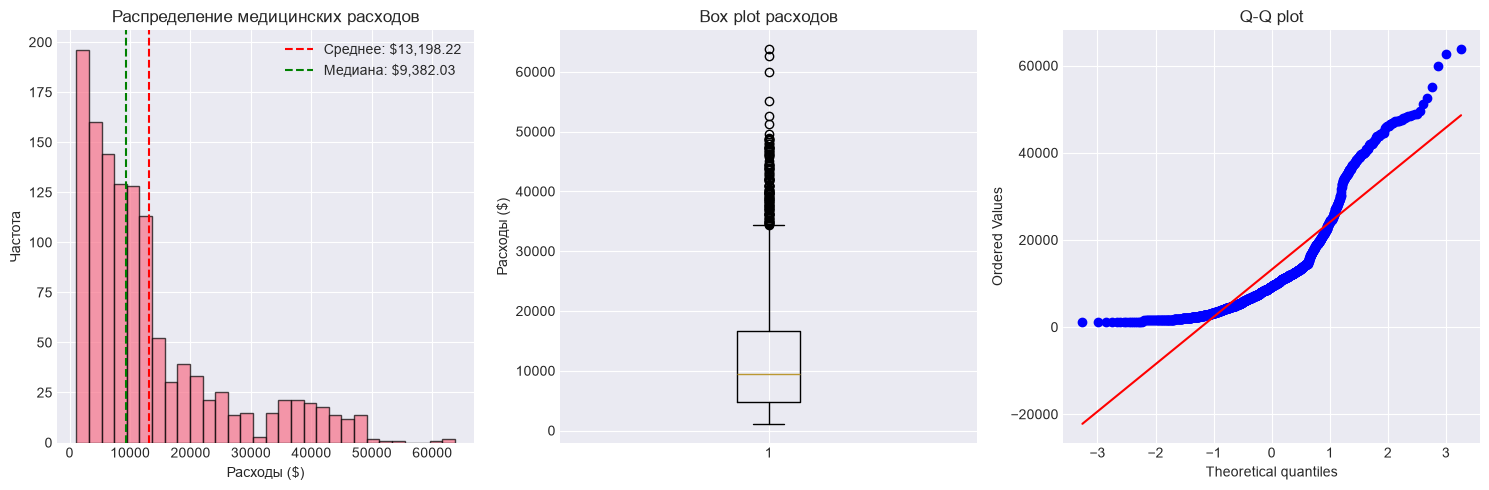


Статистики целевой переменной:
Среднее: $13,198.22
Медиана: $9,382.03
Стандартное отклонение: $12,001.81
Минимум: $1,121.87
Максимум: $63,770.43
Асимметрия (skewness): 1.51
Эксцесс (kurtosis): 1.61


In [5]:
target_column = eda_params['target_column']
print(f"АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: {target_column}")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df[target_column], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение медицинских расходов')
axes[0].set_xlabel('Расходы ($)')
axes[0].set_ylabel('Частота')
axes[0].axvline(df[target_column].mean(), color='red', linestyle='--', label=f'Среднее: ${df[target_column].mean():,.2f}')
axes[0].axvline(df[target_column].median(), color='green', linestyle='--', label=f'Медиана: ${df[target_column].median():,.2f}')
axes[0].legend()

axes[1].boxplot(df[target_column])
axes[1].set_title('Box plot расходов')
axes[1].set_ylabel('Расходы ($)')

from scipy import stats
stats.probplot(df[target_column], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout()
plt.savefig('data/processed/target_variable_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nСтатистики целевой переменной:")
print(f"Среднее: ${df[target_column].mean():,.2f}")
print(f"Медиана: ${df[target_column].median():,.2f}")
print(f"Стандартное отклонение: ${df[target_column].std():,.2f}")
print(f"Минимум: ${df[target_column].min():,.2f}")
print(f"Максимум: ${df[target_column].max():,.2f}")
print(f"Асимметрия (skewness): {df[target_column].skew():.2f}")
print(f"Эксцесс (kurtosis): {df[target_column].kurtosis():.2f}")

## 1.6. Анализ категориальных признаков

АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Средние расходы по sex:
  female: $12,477.14
  male: $13,912.37

Средние расходы по smoker:
  no: $8,419.00
  yes: $31,825.85

Средние расходы по region:
  northwest: $12,206.03
  southwest: $12,392.22
  northeast: $13,200.45
  southeast: $14,829.26


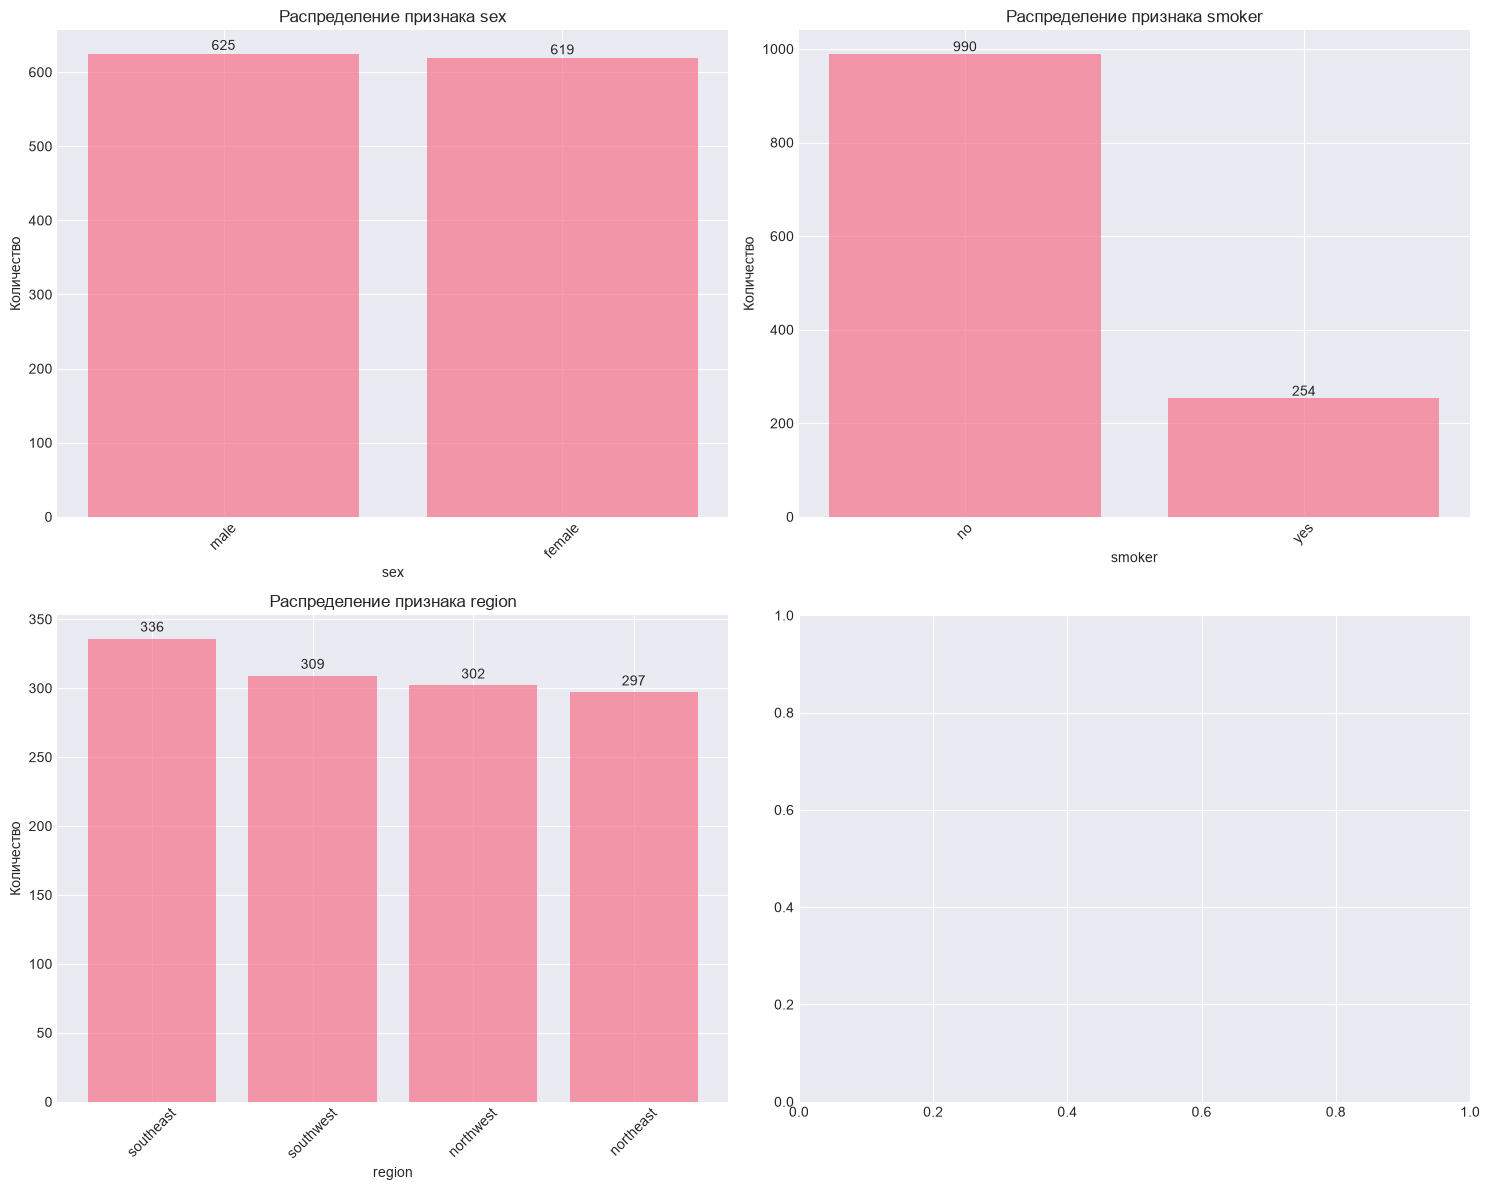

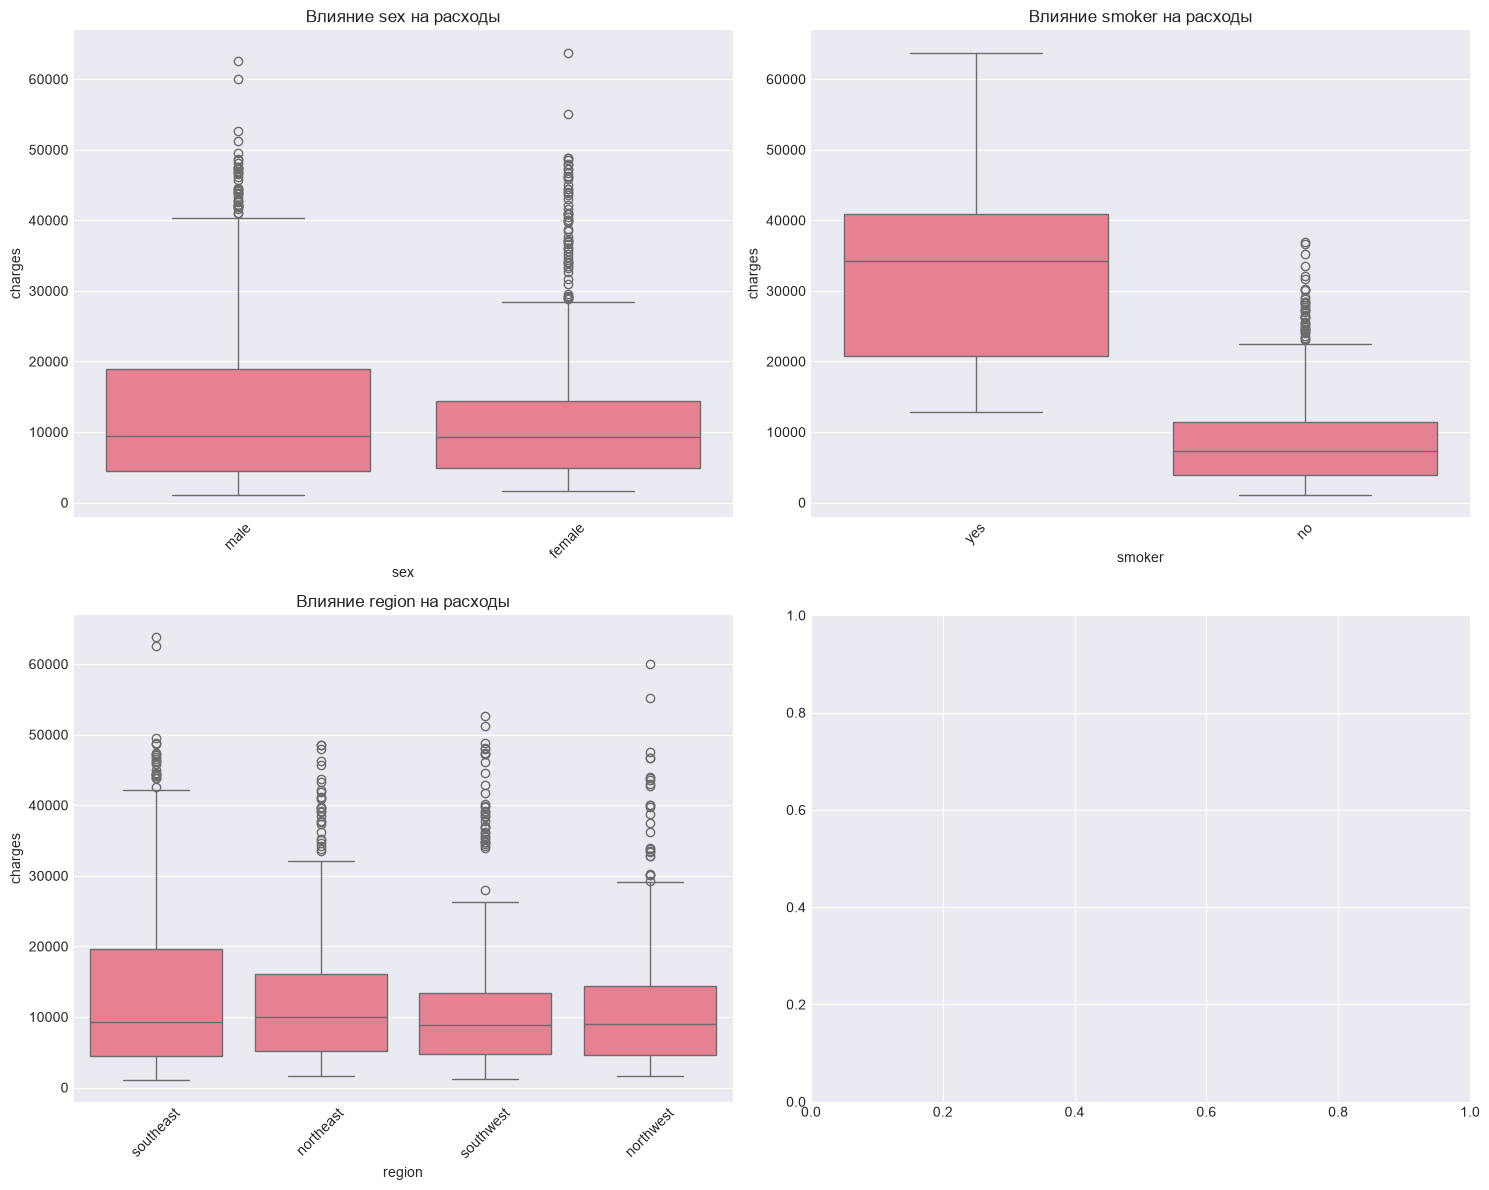

In [6]:
categorical_features = eda_params['categorical_features']
print("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    value_counts = df[feature].value_counts()
    axes[idx].bar(value_counts.index, value_counts.values, alpha=0.7)
    axes[idx].set_title(f'Распределение признака {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Количество')
    axes[idx].tick_params(axis='x', rotation=45)
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 5, str(v), ha='center')
    
    feature_means = df.groupby(feature)[target_column].mean().sort_values()
    print(f"\nСредние расходы по {feature}:")
    for category, mean_cost in feature_means.items():
        print(f"  {category}: ${mean_cost:,.2f}")

plt.tight_layout()
plt.savefig('data/processed/categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    df_box = df.copy()
    means = df_box.groupby(feature)[target_column].transform('mean')
    df_box_sorted = df_box.iloc[(-means).argsort()]
    sns.boxplot(x=feature, y=target_column, data=df_box_sorted, ax=axes[idx])
    axes[idx].set_title(f'Влияние {feature} на расходы')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/processed/categorical_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7. Анализ числовых признаков

АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


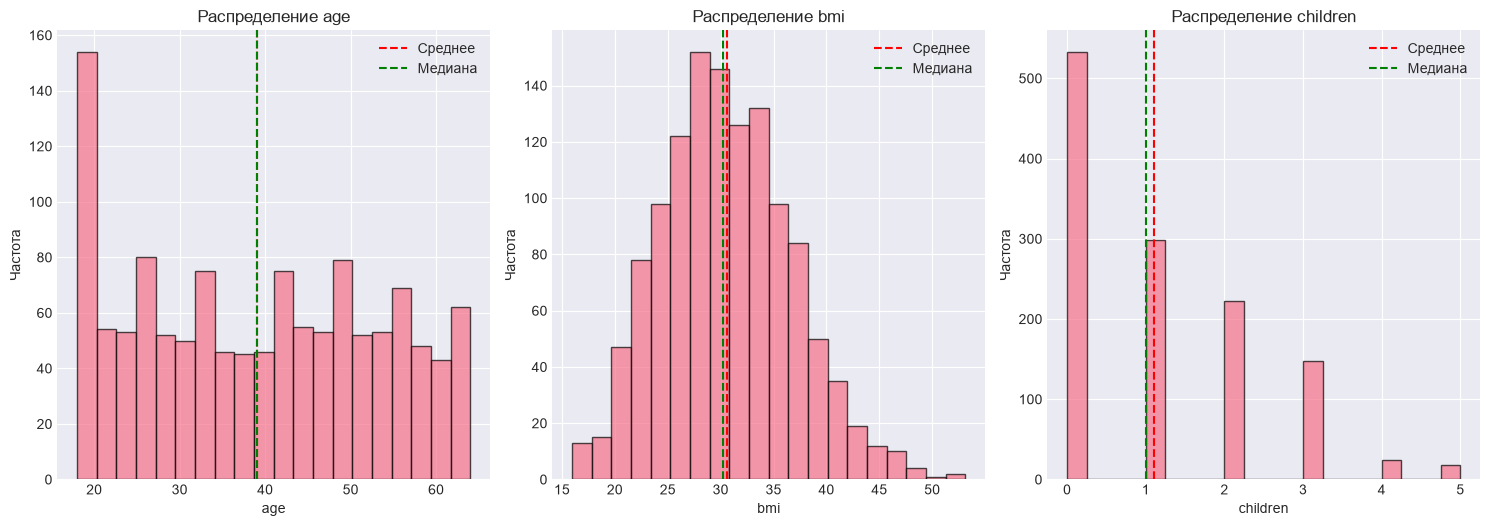


Детальная статистика:
               age          bmi     children
count  1244.000000  1244.000000  1244.000000
mean     39.088424    30.582858     1.103698
std      14.055295     6.159513     1.215885
min      18.000000    15.960000     0.000000
25%      26.000000    26.060000     0.000000
50%      39.000000    30.210000     1.000000
75%      51.000000    34.618750     2.000000
max      64.000000    53.130000     5.000000


In [7]:
numerical_features = eda_params['numerical_features']
print("АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Частота')
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', label='Среднее')
    axes[idx].axvline(df[feature].median(), color='green', linestyle='--', label='Медиана')
    axes[idx].legend()

for idx in range(len(numerical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('data/processed/numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nДетальная статистика:")
print(df[numerical_features].describe())

## 1.8. Корреляционный анализ

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


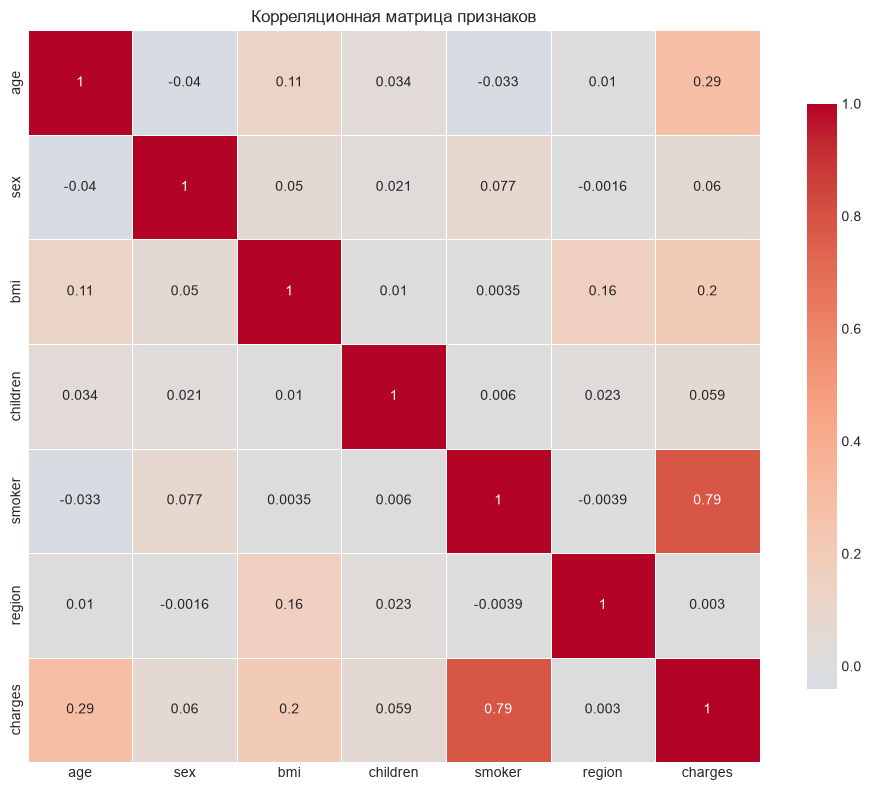


Корреляция признаков с целевой переменной:
  smoker: 0.786 (сильная положительная корреляция)
  age: 0.294 (слабая положительная корреляция)
  bmi: 0.200 (слабая положительная корреляция)
  sex: 0.060 (слабая положительная корреляция)
  children: 0.059 (слабая положительная корреляция)
  region: 0.003 (слабая положительная корреляция)


In [8]:
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*80)

# Кодирование категориальных переменных для корреляционного анализа
df_encoded = df.copy()
label_encoders = {}

for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[feature] = le.fit_transform(df[feature])
    label_encoders[feature] = le

# Вычисление корреляционной матрицы
correlation_matrix = df_encoded.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков')
plt.tight_layout()

# Сохраняем график
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print("\nКорреляция признаков с целевой переменной:")
correlations_with_target = correlation_matrix[target_column].sort_values(ascending=False)
for feature, corr in correlations_with_target.items():
    if feature != target_column:
        strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
        direction = "положительная" if corr > 0 else "отрицательная"
        print(f"  {feature}: {corr:.3f} ({strength} {direction} корреляция)")

## 1.9. Дополнительный анализ важности признаков

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ


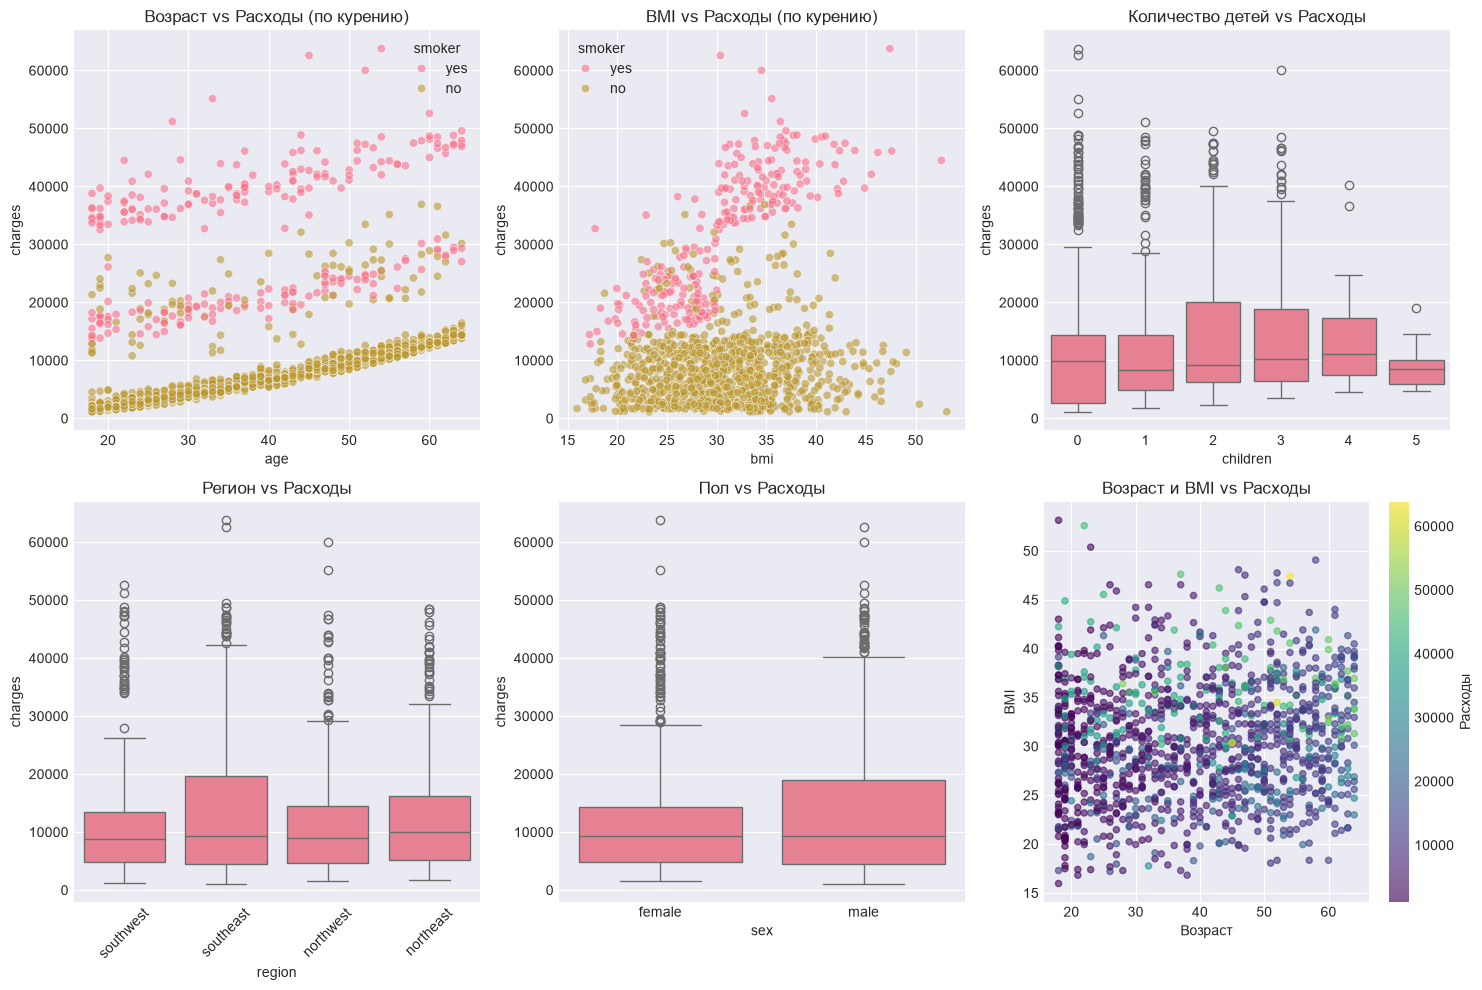

In [9]:
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*80)

df_analysis = df_encoded.copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sns.scatterplot(x='age', y=target_column, hue='smoker', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Возраст vs Расходы (по курению)')

sns.scatterplot(x='bmi', y=target_column, hue='smoker', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('BMI vs Расходы (по курению)')

sns.boxplot(x='children', y=target_column, data=df, ax=axes[2])
axes[2].set_title('Количество детей vs Расходы')

sns.boxplot(x='region', y=target_column, data=df, ax=axes[3])
axes[3].set_title('Регион vs Расходы')
axes[3].tick_params(axis='x', rotation=45)

sns.boxplot(x='sex', y=target_column, data=df, ax=axes[4])
axes[4].set_title('Пол vs Расходы')

scatter = axes[5].scatter(df['age'], df['bmi'], c=df[target_column], 
                          cmap='viridis', alpha=0.6, s=20)
axes[5].set_xlabel('Возраст')
axes[5].set_ylabel('BMI')
axes[5].set_title('Возраст и BMI vs Расходы')
plt.colorbar(scatter, ax=axes[5], label='Расходы')

plt.tight_layout()
plt.savefig('data/processed/feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.10. Выводы и формирование результатов

In [10]:
print("ВЫВОДЫ EDA АНАЛИЗА")
print("="*80)

# Формируем словарь с результатами
eda_results = {
    "dataset_info": {
        "total_samples": len(df),
        "total_features": len(df.columns) - 1,
        "missing_values": int(df.isnull().sum().sum()),
        "target_variable": target_column
    },
    "target_analysis": {
        "mean": float(df[target_column].mean()),
        "median": float(df[target_column].median()),
        "std": float(df[target_column].std()),
        "skewness": float(df[target_column].skew()),
        "kurtosis": float(df[target_column].kurtosis())
    },
    "correlation_analysis": {},
    "feature_importance": {},
    "recommendations": []
}

# Сохраняем корреляции
for feature, corr in correlations_with_target.items():
    if feature != target_column:
        eda_results["correlation_analysis"][feature] = float(corr)

# Определяем важность признаков на основе анализа
feature_importance = {
    'smoker': 'Очень высокая - курение значительно увеличивает расходы',
    'age': 'Высокая - расходы растут с возрастом',
    'bmi': 'Средняя - высокий BMI увеличивает расходы',
    'children': 'Средняя - больше детей увеличивает расходы',
    'region': 'Низкая - незначительное влияние на расходы',
    'sex': 'Очень низкая - практически не влияет на расходы'
}

eda_results["feature_importance"] = feature_importance

# Рекомендации
recommendations = [
    "Курение (smoker) - наиболее важный признак, требует обязательного включения в модель",
    "Возраст (age) - важный предиктор, показывает линейную зависимость с расходами",
    "BMI - важный признак, особенно в комбинации с курением",
    "Количество детей (children) - умеренное влияние на расходы",
    "Регион (region) - слабое влияние, но может быть полезен в комбинации с другими признаками",
    "Пол (sex) - минимальное влияние, можно исключить для упрощения модели",
    "Рекомендуется логарифмирование целевой переменной из-за правосторонней асимметрии",
    "Следует рассмотреть создание полиномиальных признаков для возраста и BMI"
]

eda_results["recommendations"] = recommendations

# Вывод результатов
print("\n1. Информация о датасете:")
print(f"   - Количество образцов: {eda_results['dataset_info']['total_samples']}")
print(f"   - Количество признаков: {eda_results['dataset_info']['total_features']}")
print(f"   - Пропущенные значения: {eda_results['dataset_info']['missing_values']}")

print("\n2. Анализ целевой переменной:")
print(f"   - Среднее: ${eda_results['target_analysis']['mean']:,.2f}")
print(f"   - Медиана: ${eda_results['target_analysis']['median']:,.2f}")
print(f"   - Стандартное отклонение: ${eda_results['target_analysis']['std']:,.2f}")
print(f"   - Асимметрия: {eda_results['target_analysis']['skewness']:.2f}")
print("   - Вывод: Распределение смещено вправо, рекомендуется логарифмирование")

print("\n3. Важность признаков:")
for feature, importance in feature_importance.items():
    print(f"   - {feature}: {importance}")

print("\n4. Рекомендации по выбору признаков:")
for i, rec in enumerate(recommendations, 1):
    print(f"   {i}. {rec}")

print("\n5. Рекомендуемый набор признаков для модели:")
print("   Основные: smoker, age, bmi")
print("   Дополнительные: children")
print("   Опциональные: region (one-hot encoding)")
print("   Исключить: sex (минимальное влияние)")

# Создаем папку для результатов
os.makedirs('data/processed', exist_ok=True)

# Сохранение полных результатов EDA
with open('data/processed/eda_results.json', 'w', encoding='utf-8') as f:
    json.dump(eda_results, f, indent=2, ensure_ascii=False)

# Создание файла с плоскими метриками для DVC
dvc_metrics = {
    # Метрики датасета
    "dataset_size": int(df.shape[0]),
    "num_features": int(df.shape[1] - 1),
    "missing_values": int(df.isnull().sum().sum()),
    
    # Статистики целевой переменной
    "target_mean": float(df[target_column].mean()),
    "target_median": float(df[target_column].median()),
    "target_std": float(df[target_column].std()),
    "target_min": float(df[target_column].min()),
    "target_max": float(df[target_column].max()),
    "target_skewness": float(df[target_column].skew()),
    
    # Корреляции признаков с целевой переменной
    "corr_smoker": float(correlations_with_target.get('smoker', 0)),
    "corr_age": float(correlations_with_target.get('age', 0)),
    "corr_bmi": float(correlations_with_target.get('bmi', 0)),
    "corr_children": float(correlations_with_target.get('children', 0)),
    "corr_sex": float(correlations_with_target.get('sex', 0)),
    "corr_region": float(correlations_with_target.get('region', 0))
}

# Сохранение метрик для DVC
with open('data/processed/eda_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(dvc_metrics, f, indent=2)

print("\n" + "="*80)
print("✅ Результаты EDA сохранены в data/processed/eda_results.json")
print("✅ Метрики DVC сохранены в data/processed/eda_metrics.json")
print("✅ График корреляционной матрицы сохранен в data/processed/correlation_matrix.png")

ВЫВОДЫ EDA АНАЛИЗА

1. Информация о датасете:
   - Количество образцов: 1244
   - Количество признаков: 6
   - Пропущенные значения: 0

2. Анализ целевой переменной:
   - Среднее: $13,198.22
   - Медиана: $9,382.03
   - Стандартное отклонение: $12,001.81
   - Асимметрия: 1.51
   - Вывод: Распределение смещено вправо, рекомендуется логарифмирование

3. Важность признаков:
   - smoker: Очень высокая - курение значительно увеличивает расходы
   - age: Высокая - расходы растут с возрастом
   - bmi: Средняя - высокий BMI увеличивает расходы
   - children: Средняя - больше детей увеличивает расходы
   - region: Низкая - незначительное влияние на расходы
   - sex: Очень низкая - практически не влияет на расходы

4. Рекомендации по выбору признаков:
   1. Курение (smoker) - наиболее важный признак, требует обязательного включения в модель
   2. Возраст (age) - важный предиктор, показывает линейную зависимость с расходами
   3. BMI - важный признак, особенно в комбинации с курением
   4. Количе